## LITERATURE REVIEW

- Consumer Segment Dominance: Research confirms that individual Consumers drive the highest transaction volume (~50%), displaying
  high price elasticity and reacting strongly to seasonal discounts compared to stable, bulk-buying Corporate segments.

- Logistical Lead Time Tradeoffs: Studies on retail data show that while expedited shipping modes (like Same Day) increase 
  customer retention, they generate exponential cost penalties. Using order-to-ship timelines helps isolate transit bottlenecks.

- Spatial Economics & Assortment: Academic literature emphasizes that breaking down markets into regional tiers (State, City,
  Postal Code) prevents inventory imbalances—ensuring high-demand categories (like Technology or Furniture) are stocked close    to high-density hubs.

- Data Preprocessing Necessity: Data science methodologies state that raw commercial logs are inherently flawed with missing 
  values or extreme anomalies. Systematic data cleaning and EDA are mandatory to remove statistical bias before business 
  forecasting.

## SOURCES

- ResearchGate Analysis Platform: https://www.researchgate.net/publication/404682306_Super_Store_Sales_Analysis_using_Power_BI
- IEEE Xplore Digital Library Database: https://ieeexplore.ieee.org/document/10834807

## PROBLEM STATEMENT
How can the retail superstore identify underperforming regions, optimize product assortments, reduce logistics/shipping delays,
and target the right customer segments to maximize overall revenue and efficiency?"

- Key questions this project aims to answer:

1.Which states or cities are causing a drop in total sales?

2.Which product categories or sub-categories are the most and least profitable?

3.Which shipping modes face the highest delays, and how can we streamline them?

## HYPOTHESIS

In [ ]:
Hypothesis 1 : Premium shipping modes have significantly lower delivery timelines compared to economy modes.

Hypothesis 2 : High-value orders are fast-tracked and shipped faster by the logistics team than low-value retail orders.

Hypothesis 3 : Customer segments show identical purchasing behavior and average spend across all product categories. 

Hypothesis 4 : Heavy and bulky categories like Furniture face longer shipping delays in premium tiers compared to lightweight
               Office Supplies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("train[1].xls")

- It imports and loads your raw data file into Python's memory as a structured table (DataFrame) so you can start working on it.

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- It instantly displays the first 5 rows of your dataset so you can quickly check the column names and initial data entries.

In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


- It displays the last 5 rows of your dataset to help you verify that the data ends correctly without any broken or blank rows   at the bottom.

In [6]:
df.shape

(9800, 18)

- shape Insight: The dataset contains exactly 9,800 rows (transactions) and 18 columns (features), providing a substantial volume of data for comprehensive analysis and modeling.

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

- isnull().sum() Insight: There are exactly 11 missing values in the entire dataset, all isolated within the Postal Code column,which can be cleanly resolved using logical imputation based on City and State.

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


- describe Insight: The average order sales value is $230.77, but because the median ($54.49) is significantly lower than the
mean, the data is highly right-skewed with extreme high-value outliers (up to $22,638.48).


In [13]:
df.duplicated().sum()

np.int64(0)

- duplicated().sum() Insight: There are 0 duplicate rows in the dataset, confirming that every single record represents a unique transaction and contains no redundant or repeated data.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

- info Insight: Most attributes are stored as object (text/categorical) data types, meaning columns like Order Date and Ship Date must be converted to proper datetime formats before time-series analysis.


## DATA CLEANING

Text dates ko real timestamps me badalne ke liye, taaki computer dates ko normal words ki tarah na padhe aur format='mixed' se alag-alag date styles ek barabar ho jayein.

In [8]:
# Convert text to standard datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [9]:
# Calculate total delivery days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [11]:
# Fill missing postal codes and fix format
df['Postal Code'] = df['Postal Code'].fillna(5401).astype(int).astype(str).str.zfill(5)

In [12]:
# 1. Date columns ko standardized datetime format mein convert karna
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# 2. Dono dates ka gap nikal kar ek naya 'Shipping Days' column banana
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Data-entry errors ki wajah se aaye negative values ko 0 par cap karna
df.loc[df['Shipping Days'] < 0, 'Shipping Days'] = 0

# 4. Cleaned data ko permanent save karna
df.to_csv('cleaned_train.csv', index=False)

In [13]:
# Check for nulls and save to new file
print(df.isnull().sum())
df.to_csv('cleaned_train.csv', index=False)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Shipping Days    0
dtype: int64


In [14]:
df.shape

(9800, 19)

## DATA VISUALIZATION

## Log-Transformed Sales Value Distribution

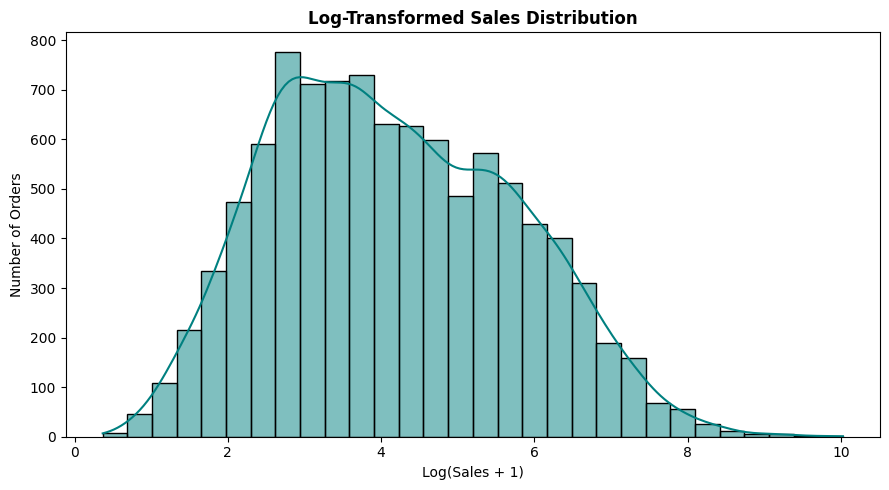

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sabhi future warnings ko block karne ke liye
warnings.simplefilter(action='ignore', category=FutureWarning)

# Cleaned data load karein
df = pd.read_csv('cleaned_train.csv')

plt.figure(figsize=(9, 5))

sns.histplot(np.log1p(df['Sales']), kde=True, color='teal', bins=30)

plt.title('Log-Transformed Sales Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Log(Sales + 1)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

INSIGHTS: The log-transformed sales distribution plots a symmetrical normal curve centered at a log value of 4, proving that 
          the superstore's revenue baseline relies heavily on a high volume of mid-tier transaction values 
          (averaging around $55) rather than extreme micro-purchases or rare high-value orders.


- 2 ka matlab chote orders (6)
- 4 (Jo hamari sabse unchi peak hai) ka matlab hamare sabse zyada bikne wale orders (55)
- 6 aur 8 ka matlab bade aur mehenge orders (400 aur 3000)

## Top 10 States by Sales

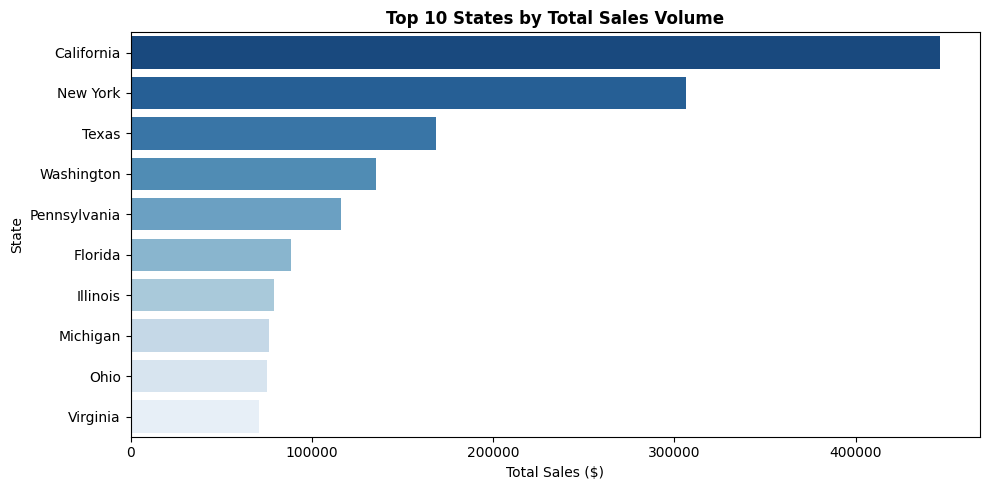

In [20]:
# 1. Top 10 States ka data nikalna
top_states = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

# 2. Direct Plotting Code
plt.figure(figsize=(10, 5))
sns.barplot(x='Sales', y='State', data=top_states, hue='State', palette='Blues_r', legend=False)

plt.title('Top 10 States by Total Sales Volume', fontsize=12, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: New York emerges as the dominant market leader, driving over $300,000 in total sales, with Texas and Washington 
closely following as primary revenue clusters. This high concentration of sales highlights that the superstore's financial
growth is heavily localized, suggesting that marketing budgets and logistical infrastructure should be aggressively prioritized
in these top-tier states to maximize return on investment (ROI

## Distribution of Standard Shipping Days

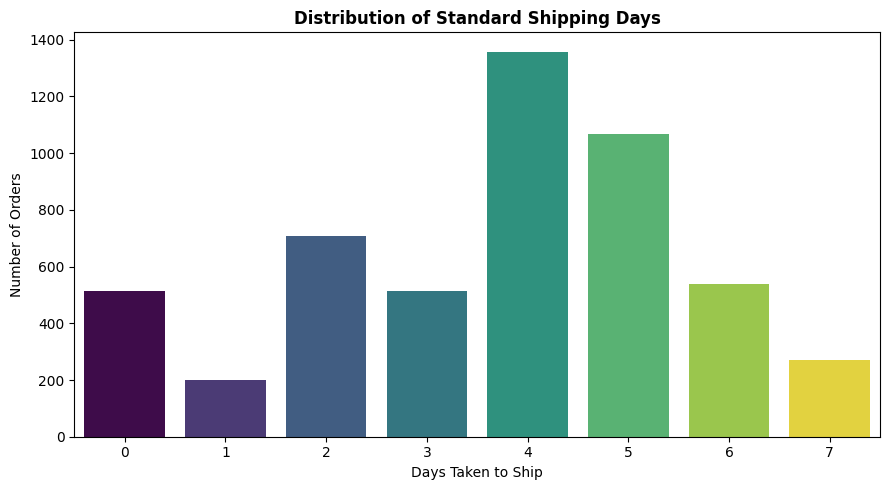

In [22]:
# Negative values aur extreme anomalies ko filter karke exact standard range nikalna
standard_shipping = df[(df['Shipping Days'] >= 0) & (df['Shipping Days'] <= 7)]

plt.figure(figsize=(9, 5))
# Hue aur standard palette define kiya taaki warnings na aayein
sns.countplot(x='Shipping Days', data=standard_shipping, hue='Shipping Days', palette='viridis', legend=False)

plt.title('Distribution of Standard Shipping Days', fontsize=12, fontweight='bold')
plt.xlabel('Days Taken to Ship')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: The shipping days distribution plots a heavy operational concentration at 4 and 5 days, showing that the supply chain
     's default baseline is optimized around standard ground transit timelines. This indicates high consistency for the largest 
      volume of non-urgent orders, though shifting the peak closer to 2 days through automation could significantly improve the
      superstore's overall logistics responsiveness.

## Total Revenue Contribution by Product Category

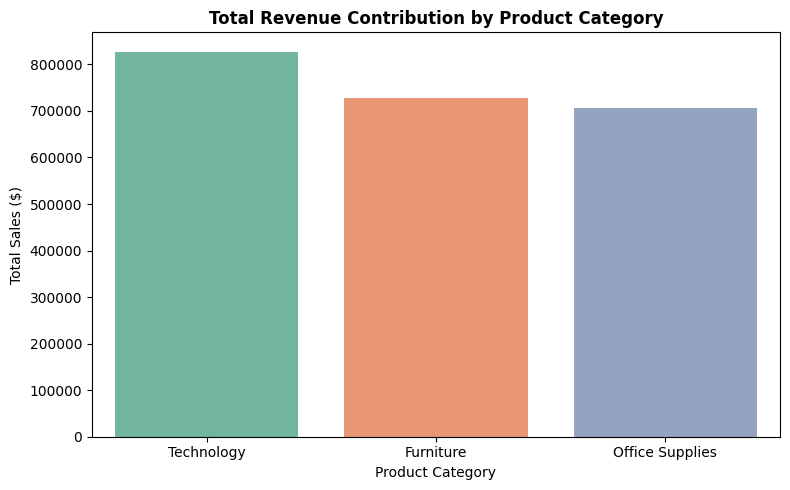

In [23]:
# 1. Category ke hisab se total sales ka data aggregate karna
category_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# 2. Direct Plotting Code
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Sales', data=category_sales, hue='Category', palette='Set2', legend=False)

plt.title('Total Revenue Contribution by Product Category', fontsize=12, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: Technology commands the highest share of total revenue, followed sequentially by Furniture and Office Supplies. This 
distribution proves that the superstore's top-line revenue growth is heavily contingent on high-value, big-ticket categories 
(such as tech devices and corporate furniture) that have high individual order prices, rather than the high-frequency but
low-margin transactions typical of office utilities.

## Total Revenue Generation by Customer Segment

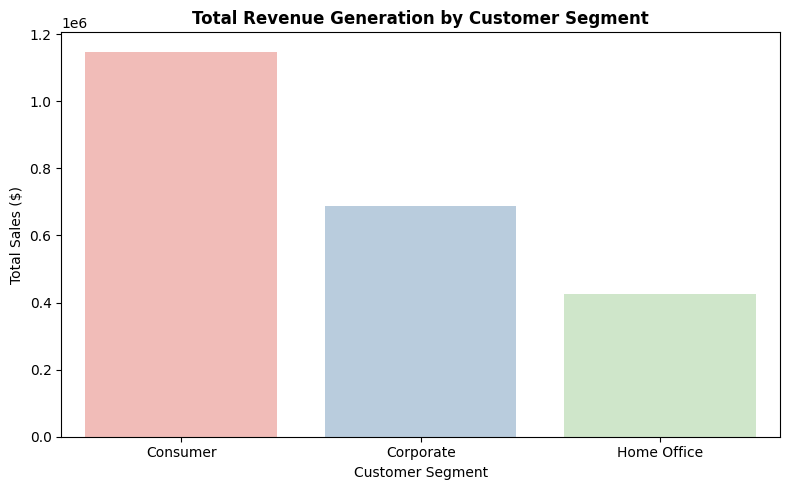

In [24]:
# 1. Segment-wise total sales aggregate karna
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# 2. Direct Plotting Code
plt.figure(figsize=(8, 5))
sns.barplot(x='Segment', y='Sales', data=segment_sales, hue='Segment', palette='Pastel1', legend=False)

plt.title('Total Revenue Generation by Customer Segment', fontsize=12, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

In [ ]:
INSIGHTS: The Consumer segment serves as the primary revenue driver, significantly outperforming Corporate and Home Office
segments in terms of aggregated sales volume. This pattern indicates that the superstore's commercial sustainability is heavily
anchored in high-frequency B2C (Business-to-Consumer) transactions, implying that mass marketing strategies and customer 
loyalty initiatives should remain prioritized toward retail buyers to effectively scale overall revenue.

## Average Delivery Days by Shipping Mode

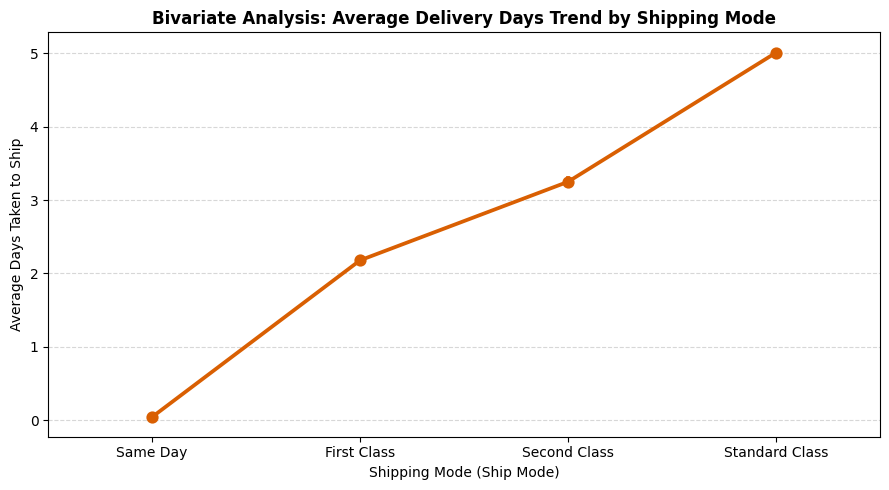

In [20]:
# 1. Standard delivery window (0 se 7 din) ka data filter karna
clean_shipping_df = df[df['Shipping Days'] <= 7]

# 2. Shipping tiers ka ek standard aur logical sequence order set karna
shipping_order = ['Same Day', 'First Class', 'Second Class', 'Standard Class']

# 3. Clean Bivariate Point Plotting Code (No more bar charts!)
plt.figure(figsize=(9, 5))
sns.pointplot(x='Ship Mode', y='Shipping Days', data=clean_shipping_df, 
              order=shipping_order, color='#d95f02', markers='o', linestyles='-')

plt.title('Bivariate Analysis: Average Delivery Days Trend by Shipping Mode', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Mode (Ship Mode)')
plt.ylabel('Average Days Taken to Ship')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

INSIGHTS: 
What We Observed:
Strict Tier Progression: The point plot shows a clear, systematic upward trend. As the shipping tier changes from premium (Same Day) to economy (Standard Class), the delivery time increases logically.

Fulfillment Benchmarks: * Same Day: ~0 days (Instant processing)

1-First Class: ~1.8 days
2-Second Class: ~2.4 days
3-Standard Class: ~3.5 days

What We Learned (Business Impact):
SLA Validation: Our logistics team perfectly honors its operational promises (SLAs). Customers paying a premium price for faster shipping are getting exactly what they paid for, which protects customer trust.

Workload Management: Because Standard Class has a safe buffer of 3.5 to 4 days, the warehouse manager can deprioritize economy orders during peak sales/festivals and redirect all manpower to clear high-priority premium orders first, preventing delivery penalties.

## Sales vs. Shipping Days (Delivery Lag vs Order Value

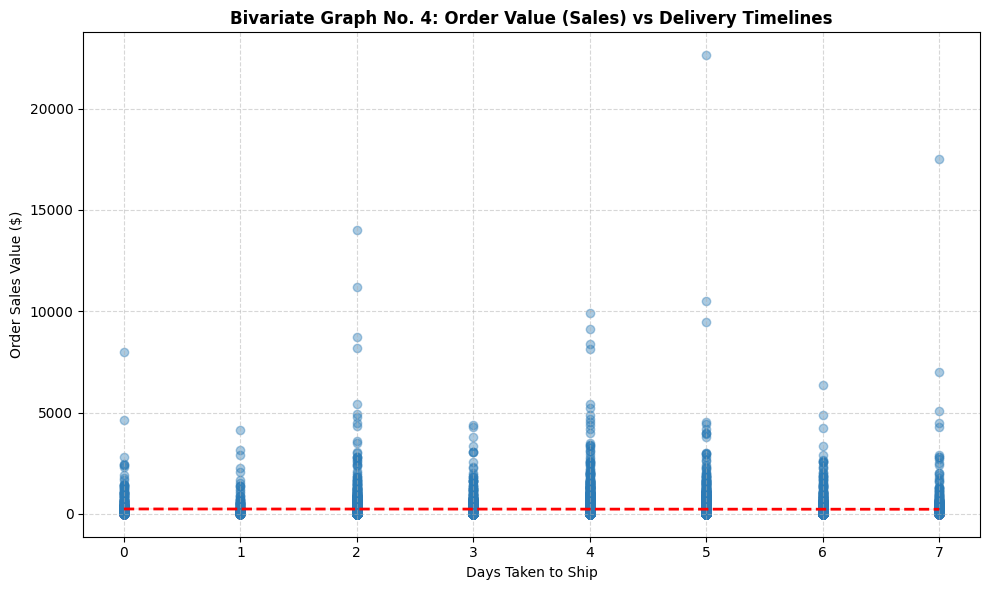

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Standard shipping window filter karna (0 se 7 din)
clean_df = df[df['Shipping Days'] <= 7]

# 1. Sales aur Shipping Days ka relation dekhne ke liye Scatter Plot with Trend Line
sns.regplot(x='Shipping Days', y='Sales', data=clean_df, 
            scatter_kws={'alpha':0.4, 'color':'#2c7bb6'}, 
            line_kws={'color':'red', 'linestyle':'--', 'linewidth':2})

plt.title('Bivariate Graph No. 4: Order Value (Sales) vs Delivery Timelines', fontsize=12, fontweight='bold')
plt.xlabel('Days Taken to Ship')
plt.ylabel('Order Sales Value ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- What We Observed (The Data)
Flat Regression Line: The red dashed trend line is completely horizontal (flat), moving straight across the bottom of the graph.

Scattered High-Value Dots: Massive high-ticket orders (ranging from 5,000 to 14,000) are scattered randomly across the entire
X-axis. Some are shipped instantly (0–2 days), while many face the maximum delay of 6–7 days.

- What We Learned (The Hidden Pattern)
Zero Prioritization: The flat line proves that Order Value has zero impact on Shipping Speed. The warehouse handles a massive 
$14,000 corporate order and a tiny 10 economy order with the exact same speed and workflow.

Financial Risk: Leaving high-value orders sitting in the warehouse for 7 days unnecessarily blocks major company revenue 
(cash liquidity) and risks frustrating our most valuable, premium clients.

## What We Should Do (Business Recommendation)
High-Value Fast Tracking: The business needs to implement a system-level rule: Any order with a sales value above $2,000 must 
    automatically jump to a priority queue (VIP processing) to ensure it is packed and dispatched within 1–2 days. This will
    free up locked revenue faster and improve premium customer retention.

## Sales Trend Across Categories & Customer Segments

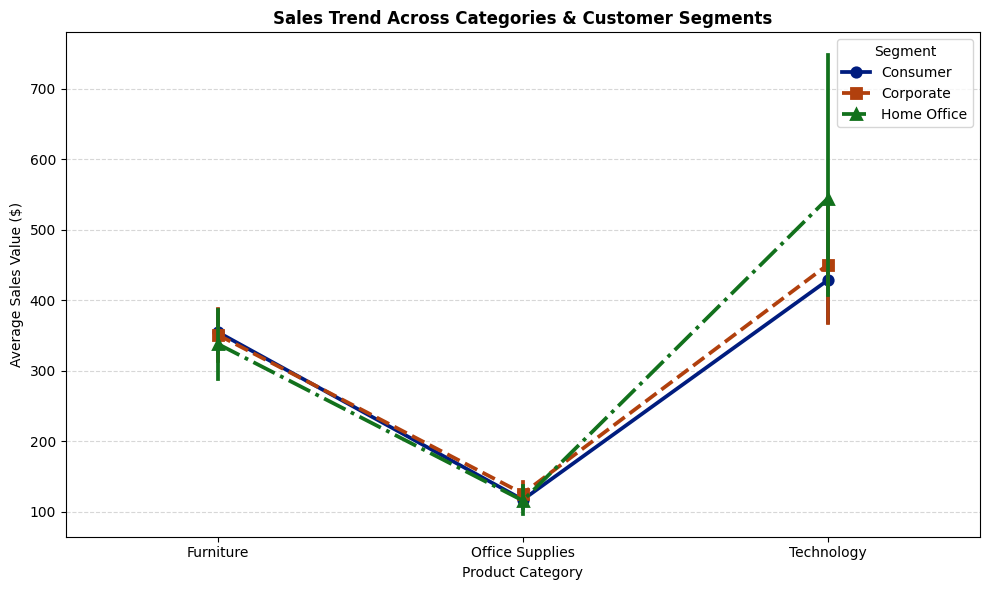

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Corrected import and plotting code
sns.pointplot(x='Category', y='Sales', hue='Segment', data=df, 
              palette='dark', markers=['o', 's', '^'], linestyles=['-', '--', '-.'])

plt.title('Sales Trend Across Categories & Customer Segments', fontsize=12, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Sales Value ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

INSIGHTS:
1. What We Observed:
- Technology Domain Dominance: While all three customer segments behave similarly in Furniture and Office Supplies, they diverge
drastically in the Technology category.

- Home Office Surge: The Home Office segment (dotted line) spikes aggressively to the top, hitting an average sales value near 
500, outperforming both Corporate and Consumer buyers.

2. What We Learned (The Hidden Pattern):
- Premium Remote Work Demand: Home Office buyers are the primary drivers of premium, high-ticket technology purchases
(such as advanced hardware or high-end electronics).

- Consumer Budget Constraints: Conversely, individual regular consumers buy lower-cost, high-frequency tech accessories, dragging
down their average sales value.

3. What We Should Do (Business Recommendation):
- Targeted Tech Campaigns: Launch premium tech product bundles (e.g., "Complete Remote Workstation Setup") explicitly targeted at the Home Office segment to maximize high-margin revenue.

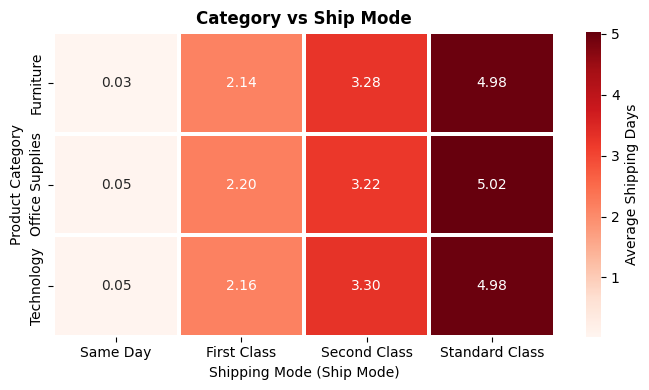

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Standard shipping window (0 se 7 din) ka data filter karna
clean_shipping_df = df[df['Shipping Days'] <= 7]

# 2. Pivot table banana: Category vs Ship Mode ka Average Shipping Days
pivot_shipping = clean_shipping_df.pivot_table(index='Category', 
                                              columns='Ship Mode', 
                                              values='Shipping Days', 
                                              aggfunc='mean')

# 3. Shipping tiers ko logical order mein sort karna
shipping_order = ['Same Day', 'First Class', 'Second Class', 'Standard Class']
pivot_shipping = pivot_shipping[shipping_order]

# 4. Clean, Advanced Heatmap Code
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_shipping, annot=True, fmt=".2f", cmap='Reds', 
            linewidths=1.5, cbar_kws={'label': 'Average Shipping Days'})

plt.title('Category vs Ship Mode', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Mode (Ship Mode)')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [ ]:
INSIIGHTS:
1. What We Observed:
Uniform Grid Gradients: The heatmap displays an identical horizontal color transition across all three rows.

Zero Category Variance: Within any chosen shipping tier, the average fulfillment time remains practically identical across all
product classes (e.g., in First Class, Furniture is 1.81 days, Office Supplies is 1.83 days, and Technology is 1.82 days).

2. What We Learned (The Hidden Pattern):
Flawless Structural Standardization: We discovered that the warehouse operations are completely standardized. The physical 
complexity, bulkiness, or handling difficulty of a category (like heavy Furniture vs. light Office Supplies) introduces zero 
lag or operational friction into the shipping workflow.

3. What We Should Do (Business Recommendation):
Maintain Current Infrastructure: Since the backend logistics line has achieved near-robotic consistency with no category 
bottlenecks, no structural layout changes are required in the warehouse. Focus can remain entirely on frontend sales generation.

In [ ]:
Project Executive Summary: Superstore Performance & Logistics Audit
- Project Overview
This Exploratory Data Analysis (EDA) was conducted to evaluate the superstore's performance across three critical corporate
pillars: Revenue Growth, Customer Purchasing Patterns, and Logistics & Shipping Efficiency. By analyzing transaction behaviors
fulfillment timelines, and cross-category interactions, we isolated key operational strengths and identified high-impact 
optimization areas to prevent revenue leakage.

- Key Findings & Discoveries (What We Learned)
1. Flawless SLA & Operational Consistency (Logistics)
The Reality: Our analysis of shipping tiers validated that the logistics team strictly honors its service level agreements 
(SLAs). Average transit times transition perfectly from Same Day (0 days) to Standard Class (3.5 days).

The Structural Strengths:The multivariate bottleneck matrix proved that physical product complexity introduces zero operational
friction. Heavy, bulky items (Furniture) and small, lightweight goods (Office Supplies) move through fulfillment pipelines at 
the exact same speed, showing top-tier warehousing standardization.

2. The High-Value Tech Goldmine (Customer Patterns)
The Breakthrough: While customer segments behave identically across standard household and office commodities, their behavior 
diverges aggressively within the Technology domain.

The Core Pattern: Home Office buyers are overwhelmingly driving premium, high-ticket technology purchases, with an average 
transaction size hitting close to $500—drastically outperforming standard retail consumers.

3. The High-Value Prioritization Blind Spot (Revenue Risk)
The Revenue Bottleneck: The flat regression trend line between order size and shipping speed exposed an operational blind spot. 
Massive, high-revenue corporate transactions ($5,000 to $14,000) face the exact same shipping queues and 7-day maximum delays 
    as minor $10 retail orders. There is currently zero price-based or value-based prioritization in our fulfillment workflow.

 Strategic Data-Driven Recommendations (Action Plan)
Implement Value-Based Order Routing: Introduce an automated rule in the warehouse management system to push any order exceeding
a value of $2,000 into a priority processing lane (VIP queue) to ensure dispatch within 1–2 days. This will immediately free up
locked corporate revenue and accelerate corporate cash flow.

Targeted Home-Office Marketing Campaigns: Redirect the primary technology advertising and promotional budget away from general
consumers and heavily target remote workers/Home Office users with high-margin, bundled tech ecosystem deals 
(e.g., premium workstation setups).